# Figure R2: Strengthened Analysis with Non-OpenAI Models

2x2 mosaic:
- **Top row**: Boxplots of token distributions (correct vs incorrect) — left Omni-MATH, right GPQA
- **Bottom row**: Accuracy vs relative reasoning token use

In [2]:
import json
import numpy as np
import pandas as pd
import tiktoken
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath, amssymb}"

cm = 1 / 2.54
enc = tiktoken.encoding_for_model('gpt-4o')

In [3]:
def load_gpt5mini_judge(filepath):
    results = []
    with open(filepath) as f:
        for line in f:
            entry = json.loads(line)
            body = entry['response']['body']
            correct = False
            for o in body['output']:
                if o['type'] == 'message':
                    parsed = json.loads(o['content'][0]['text'])
                    correct = parsed['correct'] == 'yes'
                    break
            results.append(correct)
    return results


def tiktoken_count(text):
    if not text:
        return 0
    return len(enc.encode(text))


# ============================================================
# Omni-MATH: R1 & gpt-oss-120B (GPT-5-mini judge + tiktoken)
# ============================================================

omni_other = {}

with open('data/omni_math/other_models/responses_r1.jsonl') as f:
    responses_r1 = [json.loads(l) for l in f]
g5_correct_r1 = load_gpt5mini_judge('data/omni_math/other_models/judge_results_r1.jsonl')
omni_other['r1'] = pd.DataFrame([{
    'correct': g5_correct_r1[i],
    'reasoning_tokens': tiktoken_count(resp.get('reasoning', '')),
} for i, resp in enumerate(responses_r1)])
print(f'Omni-MATH R1: {omni_other["r1"]["correct"].mean()*100:.1f}%')

with open('data/omni_math/other_models/responses_gpt_oss_120b.jsonl') as f:
    responses_oss = [json.loads(l) for l in f]
g5_correct_oss = load_gpt5mini_judge('data/omni_math/other_models/judge_results_gpt_oss-120b.jsonl')
omni_other['gpt-oss-120b'] = pd.DataFrame([{
    'correct': g5_correct_oss[i],
    'reasoning_tokens': tiktoken_count(r.get('response', '')),
} for i, r in enumerate(responses_oss)])
print(f'Omni-MATH gpt-oss-120B: {omni_other["gpt-oss-120b"]["correct"].mean()*100:.1f}%')

# ============================================================
# GPQA Diamond: R1 & gpt-oss-120B
# ============================================================

with open('data/gpqa/other_models/responses_r1.jsonl') as f:
    r1_gpqa_raw = [json.loads(l) for l in f]
gpqa_r1 = pd.DataFrame([{
    'correct': r['score'] == 1,
    'reasoning_tokens': tiktoken_count(r.get('reasoning', '')),
} for r in r1_gpqa_raw])
print(f'GPQA R1: {gpqa_r1["correct"].mean()*100:.1f}%')

with open('data/gpqa/other_models/responses_gpt_oss_120b.jsonl') as f:
    oss_gpqa_raw = [json.loads(l) for l in f]
gpqa_oss_correct = load_gpt5mini_judge('data/gpqa/other_models/judge_results_gpt_oss_120b.jsonl')
gpqa_oss = pd.DataFrame([{
    'correct': gpqa_oss_correct[i],
    'reasoning_tokens': tiktoken_count(r.get('response', '')),
} for i, r in enumerate(oss_gpqa_raw)])
print(f'GPQA gpt-oss-120B: {gpqa_oss["correct"].mean()*100:.1f}%')

Omni-MATH R1: 67.8%
Omni-MATH gpt-oss-120B: 72.4%
GPQA R1: 61.6%
GPQA gpt-oss-120B: 69.7%


/var/folders/2b/wwf70wd17zb31hbys4zvv1c80000gn/T/ipykernel_67380/1800904156.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='group', y='reasoning_tokens', data=df_plot,
/var/folders/2b/wwf70wd17zb31hbys4zvv1c80000gn/T/ipykernel_67380/1800904156.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='group', y='reasoning_tokens', data=df_plot,
/var/folders/2b/wwf70wd17zb31hbys4zvv1c80000gn/T/ipykernel_67380/1800904156.py:169: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=5.5, frameon=False, loc='lower left')


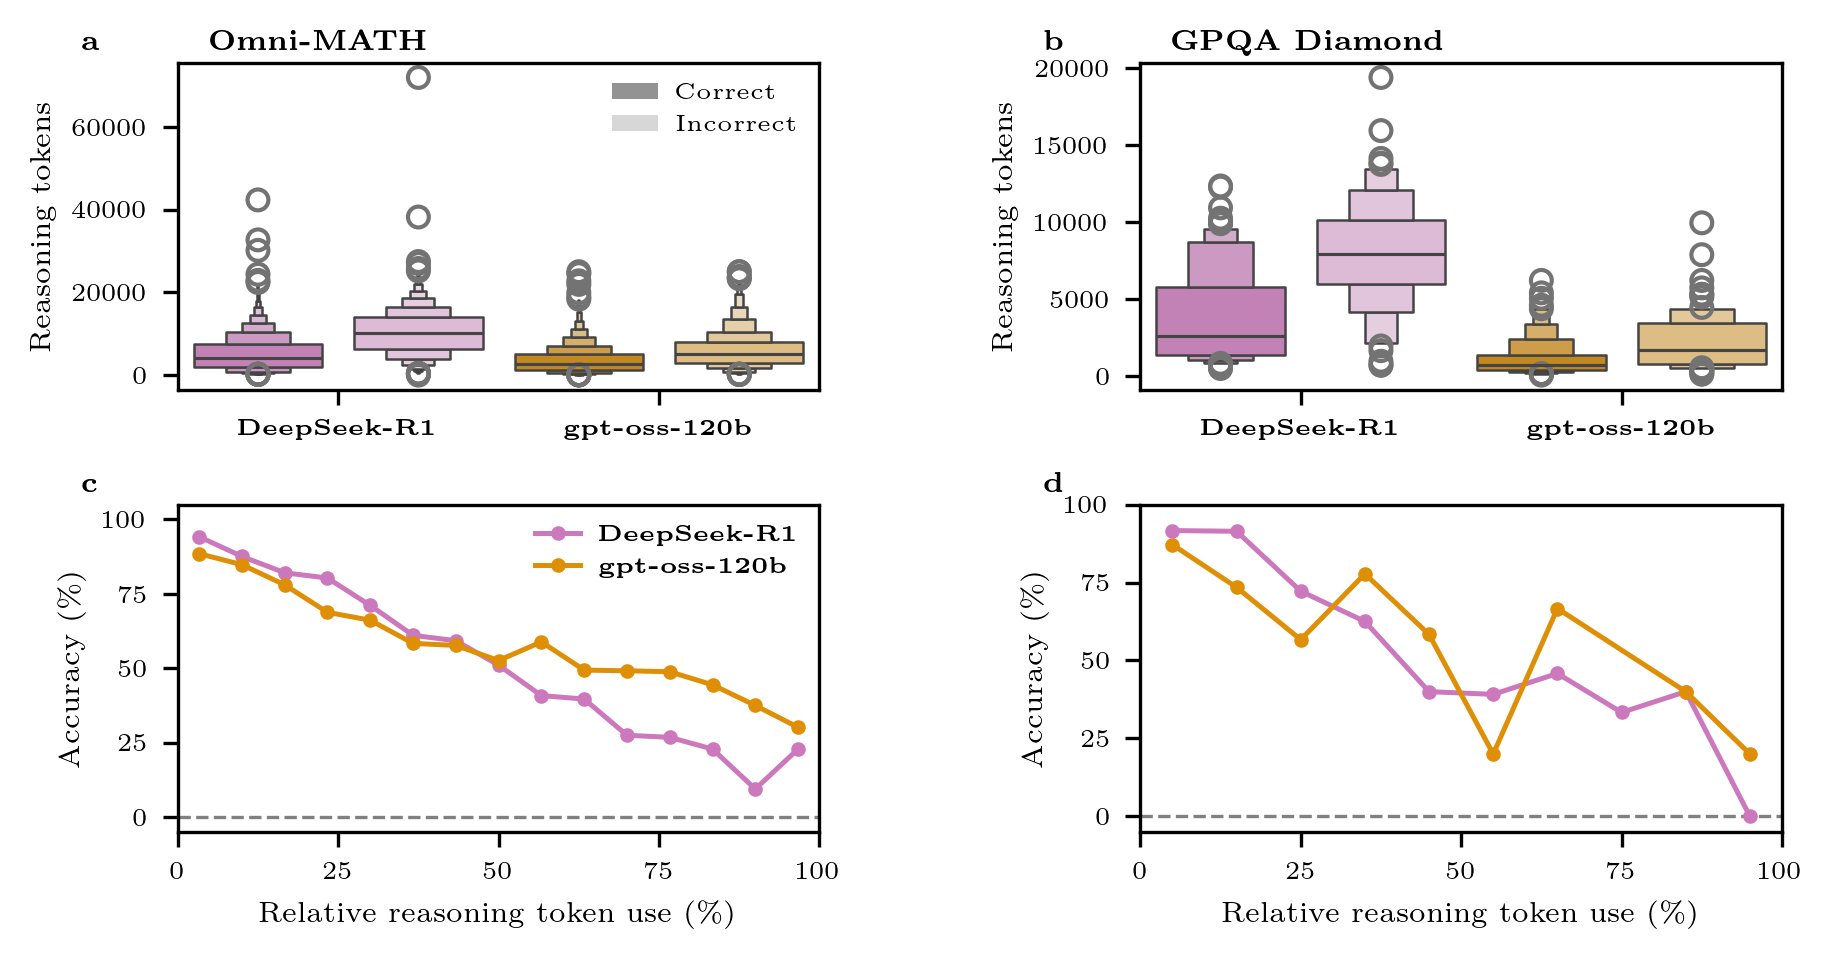

In [4]:
# ============================================================
# Figure R2: 2x2 mosaic
# ============================================================
palette = sns.color_palette("colorblind")

MODEL_COLORS = {
    'DeepSeek-R1': palette[4],
    'gpt-oss-120b': palette[1],
}
MODEL_ORDER = ['DeepSeek-R1', 'gpt-oss-120b']


def lighten_color(hex_color, amount=0.45):
    import matplotlib.colors as mcolors
    rgb = np.array(mcolors.to_rgb(hex_color))
    return tuple(rgb + (1 - rgb) * amount)


def plot_boxenplots(ax, df_all, title, panel_label):
    """Plot paired boxenplots (correct vs incorrect) per model, colored by model."""
    df_plot = df_all.copy()
    df_plot['Outcome'] = df_plot['correct'].map({True: 'Correct', False: 'Incorrect'})

    df_plot['group'] = df_plot['model'] + ' | ' + df_plot['Outcome']
    group_order = []
    palette = {}
    for model in MODEL_ORDER:
        base = MODEL_COLORS[model]
        light = lighten_color(base)
        group_order.append(f'{model} | Correct')
        group_order.append(f'{model} | Incorrect')
        palette[f'{model} | Correct'] = base
        palette[f'{model} | Incorrect'] = light

    sns.boxenplot(x='group', y='reasoning_tokens', data=df_plot,
                  ax=ax, order=group_order, palette=palette, linewidth=0.6)

    # Add hatching to incorrect boxes
    for patch in ax.patches:
        if not isinstance(patch, plt.matplotlib.patches.Rectangle):
            continue
        w = patch.get_width()
        if w <= 0:
            continue
        x_center = patch.get_x() + w / 2
        for gi, gname in enumerate(group_order):
            if abs(x_center - gi) < 0.45 and '| Incorrect' in gname:
                model = gname.split(' | ')[0]
                patch.set_hatch('///')
                patch.set_edgecolor(MODEL_COLORS[model])
                break

    ax.set_xticks([0.5, 2.5])
    ax.set_xticklabels([rf'\textbf{{{m}}}' for m in MODEL_ORDER], fontsize=5.5)
    ax.set_xlabel('', fontsize=7)
    ax.set_ylabel('Reasoning tokens', fontsize=7)
    ax.tick_params(axis='y', labelsize=6)
    ax.text(0.05, 1.1, rf'\textbf{{{title}}}', ha='left', weight='bold',
           va='top', transform=ax.transAxes, fontsize=7)
    legend = ax.get_legend()
    if legend:
        legend.remove()


def compute_relative_accuracy(df, n_bins=20):
    """Compute accuracy in bins of relative token use (0-100%), normalized by p99."""
    tokens = df['reasoning_tokens'].values
    correct = df['correct'].values
    p99 = np.percentile(tokens, 99)
    rel_tokens = np.clip(tokens / p99, 0, 1)  # clip beyond p99 into last bin
    bins = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2 * 100  # scale to 0-100%
    accs = []
    for i in range(len(bins) - 1):
        lo, hi = bins[i], bins[i + 1]
        if i == len(bins) - 2:
            mask = (rel_tokens >= lo) & (rel_tokens <= hi)
        else:
            mask = (rel_tokens >= lo) & (rel_tokens < hi)
        n = np.sum(mask)
        accs.append(np.mean(correct[mask]) * 100 if n >= 5 else np.nan)
    return bin_centers, np.array(accs)

palette = sns.color_palette("colorblind")
line_styles = {
    'DeepSeek-R1':  {'color': palette[4], 'marker': 'o', 'label': r'\textbf{DeepSeek-R1}'},
    'gpt-oss-120b': {'color': palette[1], 'marker': 'o', 'label': r'\textbf{gpt-oss-120b}'},
}


# ---- Figure ----
fig, axes = plt.subplot_mosaic(
    [['box_omni', 'box_gpqa'],
     ['curve_omni', 'curve_gpqa']],
    figsize=(6.9, (2 * 4.23) * cm),
    gridspec_kw={'height_ratios': [1, 1], 'wspace': 0.5, 'hspace': 0.35},
    dpi=300,
)

# Prepare data
df_omni_r1 = omni_other['r1'].copy(); df_omni_r1['model'] = 'DeepSeek-R1'
df_omni_oss = omni_other['gpt-oss-120b'].copy(); df_omni_oss['model'] = 'gpt-oss-120b'
df_omni_all = pd.concat([df_omni_r1, df_omni_oss], ignore_index=True)

df_gpqa_r1 = gpqa_r1.copy(); df_gpqa_r1['model'] = 'DeepSeek-R1'
df_gpqa_oss = gpqa_oss.copy(); df_gpqa_oss['model'] = 'gpt-oss-120b'
df_gpqa_all = pd.concat([df_gpqa_r1, df_gpqa_oss], ignore_index=True)

# Top row: boxenplots
plot_boxenplots(axes['box_omni'], df_omni_all, 'Omni-MATH', 'a')
plot_boxenplots(axes['box_gpqa'], df_gpqa_all, 'GPQA Diamond', 'b')

# Panel labels for boxenplots
axes['box_omni'].text(-0.15, 1.1, r'\textbf{a}', ha='left', weight='bold',
        va='top', transform=axes['box_omni'].transAxes, fontsize=7)
axes['box_gpqa'].text(-0.15, 1.1, r'\textbf{b}', ha='left', weight='bold',
        va='top', transform=axes['box_gpqa'].transAxes, fontsize=7)

# Shared legend for boxenplots (saturated = correct, light + hatched = incorrect)
legend_elements = [
    Patch(facecolor='grey', alpha=0.85, label='Correct'),
    Patch(facecolor='#d0d0d0', alpha=0.85, label='Incorrect'),
]
axes['box_omni'].legend(handles=legend_elements, fontsize=5.5, loc='upper right',
                        framealpha=0.9, edgecolor='none')

# Bottom-left (c): Omni-Math accuracy vs relative tokens (0-100%)
ax = axes['curve_omni']
for name, df_model in [('DeepSeek-R1', omni_other['r1']),
                        ('gpt-oss-120b', omni_other['gpt-oss-120b'])]:
    centers, accs = compute_relative_accuracy(df_model, n_bins=15)
    valid = ~np.isnan(accs)
    s = line_styles[name]
    ax.plot(centers[valid], accs[valid], '-', color=s['color'],
            marker=s['marker'], markersize=2.5, linewidth=1.2, label=s['label'])

ax.set_ylim(-5, 105)
ax.plot([0, 100], [0, 0], '--', linewidth=0.8, zorder=-1, color='grey')
ax.set_xlim(0, 100)
ax.set_xlabel(r'Relative reasoning token use (\%)', fontsize=7)
ax.set_ylabel(r'Accuracy (\%)', fontsize=7)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xticklabels([0, 25, 50, 75, 100], fontsize=6)
ax.set_yticks([0, 25, 50, 75, 100])
ax.set_yticklabels([0, 25, 50, 75, 100], fontsize=6)
ax.legend(fontsize=5.5, frameon=False, loc='upper right')
ax.text(-0.15, 1.1, r'\textbf{c}', ha='left', weight='bold',
        va='top', transform=ax.transAxes, fontsize=7)

# Bottom-right (d): GPQA accuracy vs relative tokens (0-100%)
ax = axes['curve_gpqa']
for name, df_model in [('DeepSeek-R1', gpqa_r1),
                        ('gpt-oss-120b', gpqa_oss)]:
    centers, accs = compute_relative_accuracy(df_model, n_bins=10)
    valid = ~np.isnan(accs)
    s = line_styles[name]
    ax.plot(centers[valid], accs[valid], '-', color=s['color'],
            marker=s['marker'], markersize=2.5, linewidth=1.2)

ax.set_ylim(-5, 100)
ax.plot([0,100], [0,0], '--', color='grey', linewidth=0.8, zorder=-1)
ax.set_xlim(0, 100)
ax.set_xlabel(r'Relative reasoning token use (\%)', fontsize=7)
ax.set_ylabel(r'Accuracy (\%)', fontsize=7)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xticklabels([0, 25, 50, 75, 100], fontsize=6)
ax.set_yticks([0, 25, 50, 75, 100])
ax.set_yticklabels([0, 25, 50, 75, 100], fontsize=6)
ax.legend(fontsize=5.5, frameon=False, loc='lower left')
ax.text(-0.15, 1.1, r'\textbf{d}', ha='left', weight='bold',
        va='top', transform=ax.transAxes, fontsize=7)

plt.savefig('figures/FigureR2.pdf', dpi=300, bbox_inches='tight')
plt.show()